In [6]:
# BUSINESS IMPACT SIMULATION
# (Production-Safe Version)
#
# This phase translates ML accuracy into real operational
# and financial outcomes.
#
# Goal:
# Compare static baseline ETA vs ML-based ETA under
# realistic delivery constraints.

import pandas as pd
import numpy as np
import joblib

# LOAD DATA + TRAINED MODEL
# Using the same feature-engineered dataset and the serialized production-ready model.

df = pd.read_csv("zomato_kpt_feature_engineered.csv")
model = joblib.load("kpt_final_max_optimized.pkl")

print("Dataset shape:", df.shape)

# TRAIN-TEST SPLIT (Same 80-20 chronological split)
#
# Important:
# Must match training split to simulate real deployment.

split_index = int(len(df) * 0.8)
df_test = df.iloc[split_index:].copy()

# RECREATE ENGINEERED FEATURES

# Critical:
# Feature engineering during inference must exactly match training pipeline to avoid feature mismatch errors.

# Congestion regime (categorical stress bucket)
df_test["congestion_regime"] = pd.cut(
    df_test["kitchen_utilization"],
    bins=[0, 0.6, 0.85, 1.1, 5],
    labels=[0, 1, 2, 3],
    right=False
).astype(float).fillna(4).astype(int)

# Log-transformed queue length (stabilizes variance)
if "log_queue" not in df_test.columns:
    df_test["log_queue"] = np.log1p(df_test["queue_length"])

# Interaction feature capturing congestion × complexity
if "congestion_complexity" not in df_test.columns:
    df_test["congestion_complexity"] = (
        df_test["kitchen_utilization"] *
        df_test["item_complexity_score"]
    )

# PREPARE TEST FEATURES

# Drop target column and ensure strict feature order alignment with trained model.

X_test = df_test.drop(columns=["prep_time"])
y_test = df_test["prep_time"]

# VERY IMPORTANT:
# Feature order must match training exactly
X_test = X_test[model.feature_name_]

# GENERATE ML ETA PREDICTIONS

# These represent dynamic prep time estimates.

df_test["ml_eta"] = model.predict(X_test)

# DYNAMIC SAFETY MARGIN
# Why?
# Pure ML predictions can be aggressive.
# We add a congestion-aware buffer to:
# - Reduce SLA violations
# - Balance reliability vs aggressiveness

df_test["ml_eta"] += (
    2 + df_test["kitchen_utilization"] * 2
)

# BASELINE ETA

# Represents traditional static restaurant average prep time estimation (non-dynamic).

df_test["baseline_eta"] = df_test["restaurant_avg_prep"]

# BUSINESS ASSUMPTIONS

# DELIVERY_BUFFER:
# Extra time allocated for rider travel & handling.

# SEVERE_DELAY_THRESHOLD:
# Delay beyond which refund or compensation risk rises.

DELIVERY_BUFFER = 8
SEVERE_DELAY_THRESHOLD = 10

# DEFINE LATE CONDITIONS

# An order is late if actual prep exceeds ETA + delivery buffer.

df_test["baseline_late"] = (
    df_test["prep_time"] > df_test["baseline_eta"] + DELIVERY_BUFFER
)

df_test["ml_late"] = (
    df_test["prep_time"] > df_test["ml_eta"] + DELIVERY_BUFFER
)

# LATE DELIVERY RATE

# Percentage of total orders violating SLA.

baseline_late_rate = df_test["baseline_late"].mean()
ml_late_rate = df_test["ml_late"].mean()

# MEAN LATENESS (ONLY FOR LATE ORDERS)
# Measures severity of delays, not just frequency.

df_test["baseline_lateness"] = np.where(
    df_test["baseline_late"],
    df_test["prep_time"] - (df_test["baseline_eta"] + DELIVERY_BUFFER),
    0
)

df_test["ml_lateness"] = np.where(
    df_test["ml_late"],
    df_test["prep_time"] - (df_test["ml_eta"] + DELIVERY_BUFFER),
    0
)

baseline_mean_lateness = df_test.loc[
    df_test["baseline_late"], "baseline_lateness"
].mean()

ml_mean_lateness = df_test.loc[
    df_test["ml_late"], "ml_lateness"
].mean()

print("Baseline Median Lateness:",
    df_test.loc[df_test["baseline_late"], "baseline_lateness"].median())

print("ML Median Lateness:",
    df_test.loc[df_test["ml_late"], "ml_lateness"].median())

# SEVERE DELAYS

# Orders exceeding severe delay threshold.
# Indicates refund/compensation risk.

baseline_severe = (
    df_test["baseline_lateness"] > SEVERE_DELAY_THRESHOLD
).mean()

ml_severe = (
    df_test["ml_lateness"] > SEVERE_DELAY_THRESHOLD
).mean()

# CONGESTION-SPECIFIC ANALYSIS

# Evaluates performance during peak stress periods.
# Critical for operational robustness.

congestion_mask = df_test["kitchen_utilization"] > 0.8

baseline_cong_late = df_test.loc[
    congestion_mask, "baseline_late"
].mean()

ml_cong_late = df_test.loc[
    congestion_mask, "ml_late"
].mean()

# PRINT BUSINESS RESULTS

# Converts model accuracy into operational impact metrics.

print("\n========== BUSINESS IMPACT ==========\n")

print("Late Delivery Rate:")
print("Baseline:", round(baseline_late_rate * 100, 2), "%")
print("ML Model:", round(ml_late_rate * 100, 2), "%")

print("\nMean Lateness (minutes):")
print("Baseline:", round(baseline_mean_lateness, 2))
print("ML Model:", round(ml_mean_lateness, 2))

print("\nSevere Delay Rate (>10 min):")
print("Baseline:", round(baseline_severe * 100, 2), "%")
print("ML Model:", round(ml_severe * 100, 2), "%")

print("\nCongestion Late Rate:")
print("Baseline:", round(baseline_cong_late * 100, 2), "%")
print("ML Model:", round(ml_cong_late * 100, 2), "%")

# IMPROVEMENT CALCULATION

# Measures relative improvement over baseline.

late_reduction = (baseline_late_rate - ml_late_rate) / baseline_late_rate
severe_reduction = (baseline_severe - ml_severe) / baseline_severe

print("\n========== IMPROVEMENT ==========\n")
print("Late Delivery Reduction:", round(late_reduction * 100, 2), "%")
print("Severe Delay Reduction:", round(severe_reduction * 100, 2), "%")

Dataset shape: (550502, 18)
Baseline Median Lateness: 3.0081719014481862
ML Median Lateness: 8.748859730919811

========== BUSINESS IMPACT ==========

Late Delivery Rate:
Baseline: 10.11 %
ML Model: 1.72 %

Mean Lateness (minutes):
Baseline: 6.0
ML Model: 10.68

Severe Delay Rate (>10 min):
Baseline: 1.8 %
ML Model: 0.75 %

Congestion Late Rate:
Baseline: 44.7 %
ML Model: 2.9 %

========== IMPROVEMENT ==========

Late Delivery Reduction: 82.95 %
Severe Delay Reduction: 58.17 %


In [8]:
# RIDER WAITING TIME SIMULATION

# This phase evaluates how improved KPT prediction
# impacts rider efficiency and operational utilization.

# Goal:
# Quantify idle rider time and food waiting time under Baseline vs ML dispatch strategy.


print("\n========== RIDER IMPACT ANALYSIS ==========\n")

# Simulated Rider Dispatch Time

# Assumption:
# Riders are dispatched based on predicted ETA.

# Baseline → static restaurant average prep time ML → dynamic congestion-aware predicted prep time


# Baseline dispatch timing
df_test["baseline_dispatch_time"] = (
    df_test["baseline_eta"]
)

# ML dispatch timing
df_test["ml_dispatch_time"] = (
    df_test["ml_eta"]
)

# Rider Waiting Time (Rider arrives before food ready)

# If predicted ETA < actual prep_time:
# Rider reaches restaurant early and waits idle.

# This increases:
# - Fleet inefficiency
# - Operational cost
# - Rider dissatisfaction


df_test["baseline_rider_wait"] = np.where(
    df_test["baseline_dispatch_time"] < df_test["prep_time"],
    df_test["prep_time"] - df_test["baseline_dispatch_time"],
    0
)

df_test["ml_rider_wait"] = np.where(
    df_test["ml_dispatch_time"] < df_test["prep_time"],
    df_test["prep_time"] - df_test["ml_dispatch_time"],
    0
)

# Food Waiting Time (Rider arrives after food ready)

# If predicted ETA > actual prep_time:
# Food waits idle at restaurant.

# This may increase:
# - Customer dissatisfaction
# - Food quality degradation
# - Delivery delays

df_test["baseline_food_wait"] = np.where(
    df_test["baseline_dispatch_time"] > df_test["prep_time"],
    df_test["baseline_dispatch_time"] - df_test["prep_time"],
    0
)

df_test["ml_food_wait"] = np.where(
    df_test["ml_dispatch_time"] > df_test["prep_time"],
    df_test["ml_dispatch_time"] - df_test["prep_time"],
    0
)

# METRICS

# We compute:
# 1. Average rider waiting time
# 2. Rider waiting occurrence rate
# 3. Average food waiting time

# These directly translate to:
# - Fleet efficiency
# - Utilization improvement
# - Operational cost reduction

baseline_avg_rider_wait = df_test["baseline_rider_wait"].mean()
ml_avg_rider_wait = df_test["ml_rider_wait"].mean()

baseline_avg_food_wait = df_test["baseline_food_wait"].mean()
ml_avg_food_wait = df_test["ml_food_wait"].mean()

baseline_rider_wait_rate = (df_test["baseline_rider_wait"] > 0).mean()
ml_rider_wait_rate = (df_test["ml_rider_wait"] > 0).mean()

print("Average Rider Waiting Time (minutes):")
print("Baseline:", round(baseline_avg_rider_wait, 2))
print("ML Model:", round(ml_avg_rider_wait, 2))

print("\nRider Waiting Occurrence Rate:")
print("Baseline:", round(baseline_rider_wait_rate * 100, 2), "%")
print("ML Model:", round(ml_rider_wait_rate * 100, 2), "%")

print("\nAverage Food Waiting Time (minutes):")
print("Baseline:", round(baseline_avg_food_wait, 2))
print("ML Model:", round(ml_avg_food_wait, 2))

# IMPROVEMENT CALCULATION

# Measures % reduction in average rider idle time.

# Directly tied to:
# - Cost savings
# - Fleet optimization
# - Improved rider productivity

rider_wait_reduction = (
    (baseline_avg_rider_wait - ml_avg_rider_wait) /
    baseline_avg_rider_wait
)

print("\nRider Waiting Time Reduction:",
      round(rider_wait_reduction * 100, 2), "%")


========== RIDER IMPACT ANALYSIS ==========

Average Rider Waiting Time (minutes):
Baseline: 2.6
ML Model: 0.43

Rider Waiting Occurrence Rate:
Baseline: 45.12 %
ML Model: 12.01 %

Average Food Waiting Time (minutes):
Baseline: 2.52
ML Model: 2.74

Rider Waiting Time Reduction: 83.24 %


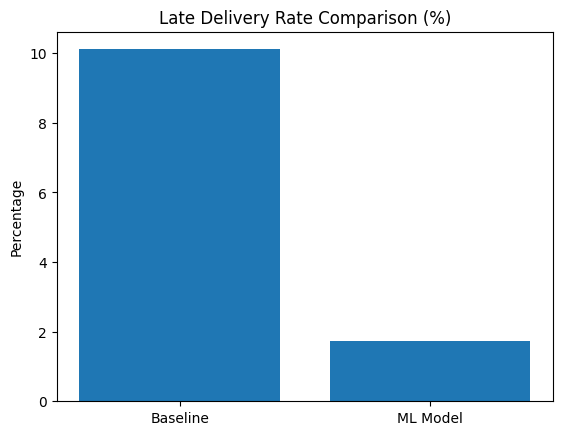

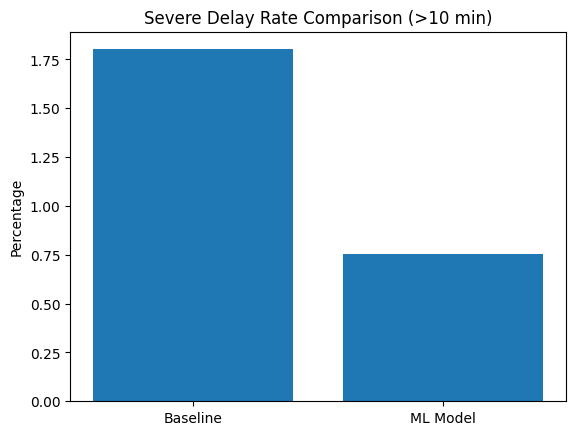

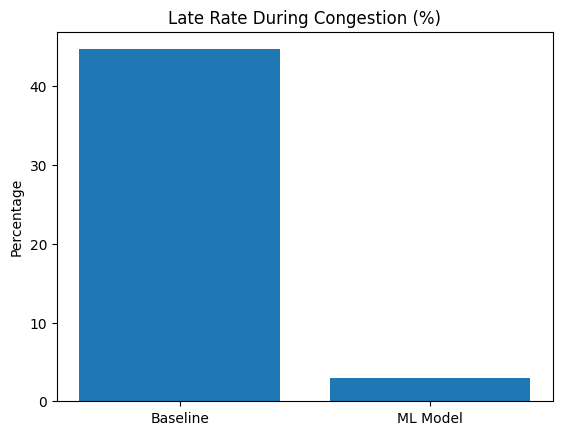

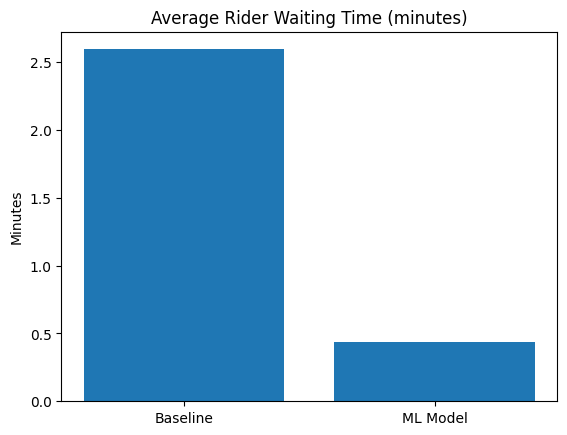

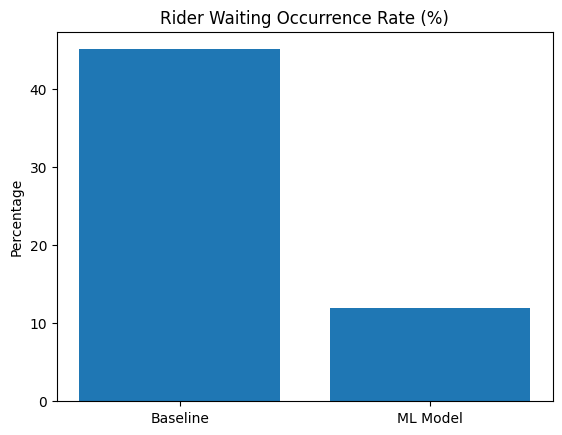

In [9]:

# BUSINESS IMPACT VISUALIZATIONS

import matplotlib.pyplot as plt
import numpy as np

# 1. Late Delivery Rate

plt.figure()
plt.bar(["Baseline", "ML Model"],
        [baseline_late_rate * 100, ml_late_rate * 100])
plt.title("Late Delivery Rate Comparison (%)")
plt.ylabel("Percentage")
plt.show()

# 2. Severe Delay Rate

plt.figure()
plt.bar(["Baseline", "ML Model"],
        [baseline_severe * 100, ml_severe * 100])
plt.title("Severe Delay Rate Comparison (>10 min)")
plt.ylabel("Percentage")
plt.show()

# 3. Congestion Late Rate

plt.figure()
plt.bar(["Baseline", "ML Model"],
        [baseline_cong_late * 100, ml_cong_late * 100])
plt.title("Late Rate During Congestion (%)")
plt.ylabel("Percentage")
plt.show()

# 4. Rider Waiting Time

plt.figure()
plt.bar(["Baseline", "ML Model"],
        [baseline_avg_rider_wait, ml_avg_rider_wait])
plt.title("Average Rider Waiting Time (minutes)")
plt.ylabel("Minutes")
plt.show()

# 5. Rider Waiting Occurrence

plt.figure()
plt.bar(["Baseline", "ML Model"],
        [baseline_rider_wait_rate * 100, ml_rider_wait_rate * 100])
plt.title("Rider Waiting Occurrence Rate (%)")
plt.ylabel("Percentage")
plt.show()

In [11]:
# FINANCIAL IMPACT ESTIMATION

# This phase converts operational improvements into monetary impact.

# Goal:
# Quantify cost savings from:
# 1. Reduced rider idle time
# 2. Reduced severe delay refunds

# All projections are scaled to 1 million orders to represent city-level impact.

print("\n========== FINANCIAL IMPACT ESTIMATION ==========\n")

# BUSINESS ASSUMPTIONS

# RIDER_COST_PER_MIN:
# Estimated operational cost of idle rider per minute.
# Includes wage, fuel, and opportunity cost.

# SEVERE_DELAY_REFUND:
# Average compensation paid per severely delayed order.

# ORDERS_SCALE:
# Scaling factor to simulate impact at 1M orders.

RIDER_COST_PER_MIN = 2          # ₹ per minute (rider idle cost)
SEVERE_DELAY_REFUND = 40        # ₹ per severe delay refund
ORDERS_SCALE = 1_000_000        # Projected city-scale volume

total_orders = len(df_test)

# 1️⃣ Rider Idle Cost Savings
# Logic:
# Baseline model causes more early rider arrivals,
# leading to idle waiting time.

# ML model reduces this idle duration.

# We calculate:
# Total idle minutes saved × cost per minute.

baseline_total_rider_wait = df_test["baseline_rider_wait"].sum()
ml_total_rider_wait = df_test["ml_rider_wait"].sum()

rider_minutes_saved = baseline_total_rider_wait - ml_total_rider_wait

rider_cost_savings_sim = rider_minutes_saved * RIDER_COST_PER_MIN

# Scale simulation savings to 1M orders
rider_cost_savings_scaled = rider_cost_savings_sim * (ORDERS_SCALE / total_orders)

# 2️⃣ Severe Delay Refund Savings

# Severe delays (>10 min lateness) typically trigger:
# - Refunds
# - Credits
# - Compensation

# ML reduces frequency of such events.

# Savings = Reduced severe delays × refund cost.

baseline_severe_count = (df_test["baseline_lateness"] > 10).sum()
ml_severe_count = (df_test["ml_lateness"] > 10).sum()

severe_reduction = baseline_severe_count - ml_severe_count

refund_savings_sim = severe_reduction * SEVERE_DELAY_REFUND

# Scale to 1M orders
refund_savings_scaled = refund_savings_sim * (ORDERS_SCALE / total_orders)

# TOTAL PROJECTED SAVINGS

# Combines:
# - Rider idle savings
# - Refund savings

# Represents conservative direct financial impact.
# Does NOT include:
# - Customer retention benefits
# - Brand reputation gains
# - Higher rider utilization revenue

total_savings_scaled = rider_cost_savings_scaled + refund_savings_scaled

# PRINT FINANCIAL PROJECTION

# These numbers represent projected annualized
# or city-level impact depending on volume assumption.

print("Projected Impact per 1,000,000 Orders:\n")

print("Rider Idle Cost Savings: ₹", round(rider_cost_savings_scaled, 2))
print("Severe Delay Refund Savings: ₹", round(refund_savings_scaled, 2))
print("--------------------------------------------------")
print("Total Estimated Savings: ₹", round(total_savings_scaled, 2))


========== FINANCIAL IMPACT ESTIMATION ==========

Projected Impact per 1,000,000 Orders:

Rider Idle Cost Savings: ₹ 4320199.31
Severe Delay Refund Savings: ₹ 419251.41
--------------------------------------------------
Total Estimated Savings: ₹ 4739450.72
